#Data Collection: Yahoo Finance (2025–2026)

In [ ]:
import yfinance as yf
import pandas as pd

# Pull hourly EUR/USD data from Yahoo Finance for Jan 2025 to Feb 2026.
# yfinance only gives hourly data for the last 730 days so this covers the recent window.
df1 = yf.download("EURUSD=X", start="2025-01-01", end="2026-02-17", interval="1h")
df1.to_csv("eurusd_hourly_26months.csv")
print(f"Total: {df1.shape}")
print(df1.head())

/tmp/ipykernel_8739/4203110623.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df1 = yf.download("EURUSD=X", start="2025-01-01", end="2026-02-17", interval="1h")
[*********************100%***********************]  1 of 1 completed

Total: (6946, 5)
Price                         Close      High       Low      Open   Volume
Ticker                     EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Datetime                                                                  
2025-01-01 05:00:00+00:00  1.035197  1.035197  1.035197  1.035197        0
2025-01-01 18:00:00+00:00  1.035947  1.036592  1.035518  1.035518        0
2025-01-01 19:00:00+00:00  1.036162  1.036269  1.035947  1.035947        0
2025-01-01 20:00:00+00:00  1.036162  1.036269  1.035947  1.036162        0
2025-01-01 21:00:00+00:00  1.035840  1.036162  1.035625  1.036162        0


# Data Collection: Twelve Data API (2024)

In [ ]:
import requests
import pandas as pd
import time

API_KEY = "fadaafd3053d486393e5bcd3e348d194"

def fetch_chunk(start_date, end_date):
    url = "https://api.twelvedata.com/time_series"
    params = {
        "symbol": "EUR/USD",
        "interval": "1h",
        "start_date": start_date,
        "end_date": end_date,
        "outputsize": 5000,
        "apikey": API_KEY,
        "format": "JSON"
    }
    r = requests.get(url, params=params)
    data = r.json()

    if "values" not in data:
        print(f"Error: {data}")
        return pd.DataFrame()

    df = pd.DataFrame(data["values"])
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.set_index("datetime").sort_index()
    df = df.astype(float)
    return df

# Twelve Data caps each request at 5000 rows so we split 2024 into quarters.
# The 15-second sleep keeps us inside the free tier limit of 8 requests per minute.
periods = [
    ("2024-01-01 00:00:00", "2024-04-01 00:00:00"),
    ("2024-04-01 00:00:00", "2024-07-01 00:00:00"),
    ("2024-07-01 00:00:00", "2024-10-01 00:00:00"),
    ("2024-10-01 00:00:00", "2025-01-01 00:00:00"),
]

chunks = []
for start, end in periods:
    print(f"Fetching {start} to {end}...")
    chunk = fetch_chunk(start, end)
    if not chunk.empty:
        chunks.append(chunk)
    time.sleep(15)

df = pd.concat(chunks).drop_duplicates().sort_index()
df.to_csv("eurusd_hourly_2024.csv")
print(f"Total rows: {len(df)}")
print(df.head())

Fetching 2024-01-01 00:00:00 to 2024-04-01 00:00:00...
Fetching 2024-04-01 00:00:00 to 2024-07-01 00:00:00...
Fetching 2024-07-01 00:00:00 to 2024-10-01 00:00:00...
Fetching 2024-10-01 00:00:00 to 2025-01-01 00:00:00...
Total rows: 6143
                        open     high      low   close
datetime                                              
2024-01-02 04:00:00  1.10440  1.10440  1.10420  1.1042
2024-01-02 05:00:00  1.10450  1.10470  1.10360  1.1038
2024-01-02 06:00:00  1.10365  1.10430  1.10365  1.1043
2024-01-02 07:00:00  1.10420  1.10470  1.10415  1.1046
2024-01-02 08:00:00  1.10465  1.10465  1.10445  1.1045


#Data Merging and Cleaning

In [ ]:
import pandas as pd

df1 = pd.read_csv("eurusd_hourly_2024.csv")
df1.columns = df1.columns.str.strip().str.lower()
df1["datetime"] = pd.to_datetime(df1["datetime"], utc=False)
df1 = df1[["datetime", "open", "high", "low", "close"]]
print(f"2024 file: {len(df1)} rows | {df1['datetime'].min()} to {df1['datetime'].max()}")

df2_raw = pd.read_csv("eurusd_hourly_26months.csv", header=[0, 1])
df2_raw.columns = ["_".join(col).strip().lower() for col in df2_raw.columns]

first_col = df2_raw.columns[0]
df2_raw = df2_raw.rename(columns={first_col: "datetime"})
df2_raw = df2_raw.iloc[1:].reset_index(drop=True)

df2_raw["datetime"] = pd.to_datetime(
    df2_raw["datetime"], utc=True, errors="coerce"
).dt.tz_localize(None)

col_map = {}
for col in df2_raw.columns:
    if "open" in col:                          col_map[col] = "open"
    elif "high" in col:                        col_map[col] = "high"
    elif "low" in col:                         col_map[col] = "low"
    elif "close" in col and "adj" not in col:  col_map[col] = "close"

df2 = df2_raw.rename(columns=col_map)[["datetime", "open", "high", "low", "close"]]
df2 = df2.dropna(subset=["open", "high", "low", "close"], how="all")
print(f"Yahoo file: {len(df2)} rows | {df2['datetime'].min()} to {df2['datetime'].max()}")

df = pd.concat([df1, df2], ignore_index=True)
df = df.sort_values("datetime").reset_index(drop=True)
df = df.drop_duplicates(subset="datetime", keep="first")

for col in ["open", "high", "low", "close"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["open", "high", "low", "close"])
df = df[df["high"] >= df["low"]].reset_index(drop=True)

print(f"\nFinal dataset: {len(df):,} rows | {df['datetime'].min()} to {df['datetime'].max()}")
df.to_csv("eurusd_clean.csv", index=False)
print("Saved: eurusd_clean.csv")

2024 file: 6143 rows | 2024-01-02 04:00:00 to 2024-12-31 23:00:00
Yahoo file: 6946 rows | 2025-01-01 05:00:00 to 2026-02-16 23:00:00

Final dataset: 13,089 rows | 2024-01-02 04:00:00 to 2026-02-16 23:00:00
Saved: eurusd_clean.csv


#Feature_Engineering

In [ ]:
import pandas as pd
import numpy as np

df_feat = df.copy()

df_feat["Returns"] = df_feat["close"].pct_change() * 100

df_feat["MA_7"]  = df_feat["close"].rolling(7).mean()
df_feat["MA_25"] = df_feat["close"].rolling(25).mean()
df_feat["MA_50"] = df_feat["close"].rolling(50).mean()

df_feat["EMA_12"] = df_feat["close"].ewm(span=12, adjust=False).mean()
df_feat["EMA_26"] = df_feat["close"].ewm(span=26, adjust=False).mean()

def compute_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    return 100 - (100 / (1 + avg_gain / avg_loss))

df_feat["RSI"] = compute_rsi(df_feat["close"])

bb_mid = df_feat["close"].rolling(20).mean()
bb_std = df_feat["close"].rolling(20).std()
df_feat["BB_Middle"]   = bb_mid
df_feat["BB_Upper"]    = bb_mid + 2 * bb_std
df_feat["BB_Lower"]    = bb_mid - 2 * bb_std
df_feat["BB_Width"]    = df_feat["BB_Upper"] - df_feat["BB_Lower"]
df_feat["BB_Position"] = (df_feat["close"] - df_feat["BB_Lower"]) / df_feat["BB_Width"]

true_range = pd.concat([
    df_feat["high"] - df_feat["low"],
    (df_feat["high"] - df_feat["close"].shift()).abs(),
    (df_feat["low"]  - df_feat["close"].shift()).abs()
], axis=1).max(axis=1)
df_feat["ATR"]         = true_range.ewm(span=14, adjust=False).mean()
df_feat["ATR_Percent"] = (df_feat["ATR"] / df_feat["close"]) * 100

df_feat["ROC_10"]   = (df_feat["close"] - df_feat["close"].shift(10)) / df_feat["close"].shift(10) * 100
df_feat["Momentum"] = df_feat["close"] - df_feat["close"].shift(10)

rows_before = len(df_feat)
df_feat = df_feat.dropna().reset_index(drop=True)
print(f"Dropped {rows_before - len(df_feat)} warm-up rows")

print(f"Rows: {len(df_feat):,} | Columns: {len(df_feat.columns)}")
print(f"Range: {df_feat['datetime'].min()} to {df_feat['datetime'].max()}")
print(df_feat.tail(3).to_string())

df_feat.to_csv("eurusd_features.csv", index=False)
print("Saved: eurusd_features.csv")

Dropped 49 warm-up rows
Rows: 13,040 | Columns: 21
Range: 2024-01-04 05:00:00 to 2026-02-16 23:00:00
                 datetime      open      high       low     close   Returns      MA_7     MA_25     MA_50    EMA_12    EMA_26        RSI  BB_Middle  BB_Upper  BB_Lower  BB_Width  BB_Position       ATR  ATR_Percent    ROC_10  Momentum
13037 2026-02-16 21:00:00  1.185677  1.185818  1.185396  1.185536 -0.023715  1.185577  1.186415  1.186623  1.185851  1.186228  42.090613   1.186240  1.187554  1.184926  0.002627     0.232216  0.000587     0.049504 -0.082988 -0.000985
13038 2026-02-16 22:00:00  1.184834  1.185958  1.184834  1.185255 -0.023700  1.185496  1.186313  1.186581  1.185759  1.186156  39.621207   1.186156  1.187496  1.184816  0.002680     0.164129  0.000659     0.055559 -0.023700 -0.000281
13039 2026-02-16 23:00:00  1.185536  1.185536  1.185115  1.185255  0.000000  1.185456  1.186234  1.186538  1.185682  1.186089  39.621207   1.186064  1.187387  1.184741  0.002645     0.194284  0.000

#Dataset Preview

In [ ]:
df_feat

,datetime,open,high,low,close,Returns,MA_7,MA_25,MA_50,EMA_12,...,RSI,BB_Middle,BB_Upper,BB_Lower,BB_Width,BB_Position,ATR,ATR_Percent,ROC_10,Momentum
0,2024-01-04 05:00:00,1.090700,1.091500,1.090300,1.090600,-0.009168,1.091193,1.093718,1.097363,1.092087,...,27.199047,1.093543,1.097739,1.089346,0.008393,0.149423,0.001596,0.146304,-0.429106,-0.004700
1,2024-01-04 06:00:00,1.090700,1.092600,1.089300,1.091800,0.110031,1.091207,1.093602,1.097115,1.092043,...,37.216433,1.093422,1.097677,1.089168,0.008509,0.309313,0.001823,0.166958,-0.164594,-0.001800
2,2024-01-04 07:00:00,1.091800,1.092400,1.091500,1.092150,0.032057,1.091200,1.093500,1.096882,1.092059,...,39.817543,1.093280,1.097503,1.089057,0.008445,0.366198,0.001700,0.155638,-0.059480,-0.000650
3,2024-01-04 08:00:00,1.092000,1.092400,1.091800,1.092300,0.013734,1.091264,1.093420,1.096642,1.092096,...,40.946727,1.093140,1.097294,1.088986,0.008307,0.398885,0.001553,0.142192,0.036633,0.000400
4,2024-01-04 09:00:00,1.092150,1.092500,1.091500,1.092200,-0.009155,1.091507,1.093336,1.096394,1.092112,...,40.402480,1.092985,1.097029,1.088941,0.008088,0.402948,0.001479,0.135452,0.045800,0.000500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13035,2026-02-16 19:00:00,1.185255,1.185818,1.185255,1.185818,0.047432,1.185637,1.186544,1.186668,1.185924,...,44.678511,1.186345,1.187633,1.185058,0.002575,0.295014,0.000663,0.055931,-0.083008,-0.000985
13036,2026-02-16 20:00:00,1.185818,1.185818,1.185536,1.185818,0.000000,1.185637,1.186471,1.186648,1.185908,...,44.678511,1.186310,1.187616,1.185005,0.002611,0.311326,0.000612,0.051636,-0.106728,-0.001267
13037,2026-02-16 21:00:00,1.185677,1.185818,1.185396,1.185536,-0.023715,1.185577,1.186415,1.186623,1.185851,...,42.090613,1.186240,1.187554,1.184926,0.002627,0.232216,0.000587,0.049504,-0.082988,-0.000985
13038,2026-02-16 22:00:00,1.184834,1.185958,1.184834,1.185255,-0.023700,1.185496,1.186313,1.186581,1.185759,...,39.621207,1.186156,1.187496,1.184816,0.002680,0.164129,0.000659,0.055559,-0.023700,-0.000281


#Lasso regression

Best alpha : 0.000046
R²         : 0.9995
    Feature  Coefficient     Abs_Coef
       open 4.589131e-02 4.589131e-02
    Returns 8.663952e-04 8.663952e-04
       high 1.339526e-05 1.339526e-05
      close 1.184486e-05 1.184486e-05
        low 4.001430e-07 4.001430e-07
   BB_Upper 3.089161e-07 3.089161e-07
      MA_25 0.000000e+00 0.000000e+00
       MA_7 0.000000e+00 0.000000e+00
      MA_50 0.000000e+00 0.000000e+00
     EMA_12 0.000000e+00 0.000000e+00
     EMA_26 0.000000e+00 0.000000e+00
        RSI 0.000000e+00 0.000000e+00
  BB_Middle 0.000000e+00 0.000000e+00
   BB_Lower 0.000000e+00 0.000000e+00
   BB_Width 0.000000e+00 0.000000e+00
BB_Position 0.000000e+00 0.000000e+00
        ATR 0.000000e+00 0.000000e+00
ATR_Percent 0.000000e+00 0.000000e+00
     ROC_10 0.000000e+00 0.000000e+00
   Momentum 0.000000e+00 0.000000e+00

Eliminated : ['MA_25', 'MA_7', 'MA_50', 'EMA_12', 'EMA_26', 'RSI', 'BB_Middle', 'BB_Lower', 'BB_Width', 'BB_Position', 'ATR', 'ATR_Percent', 'ROC_10', 'Momentu

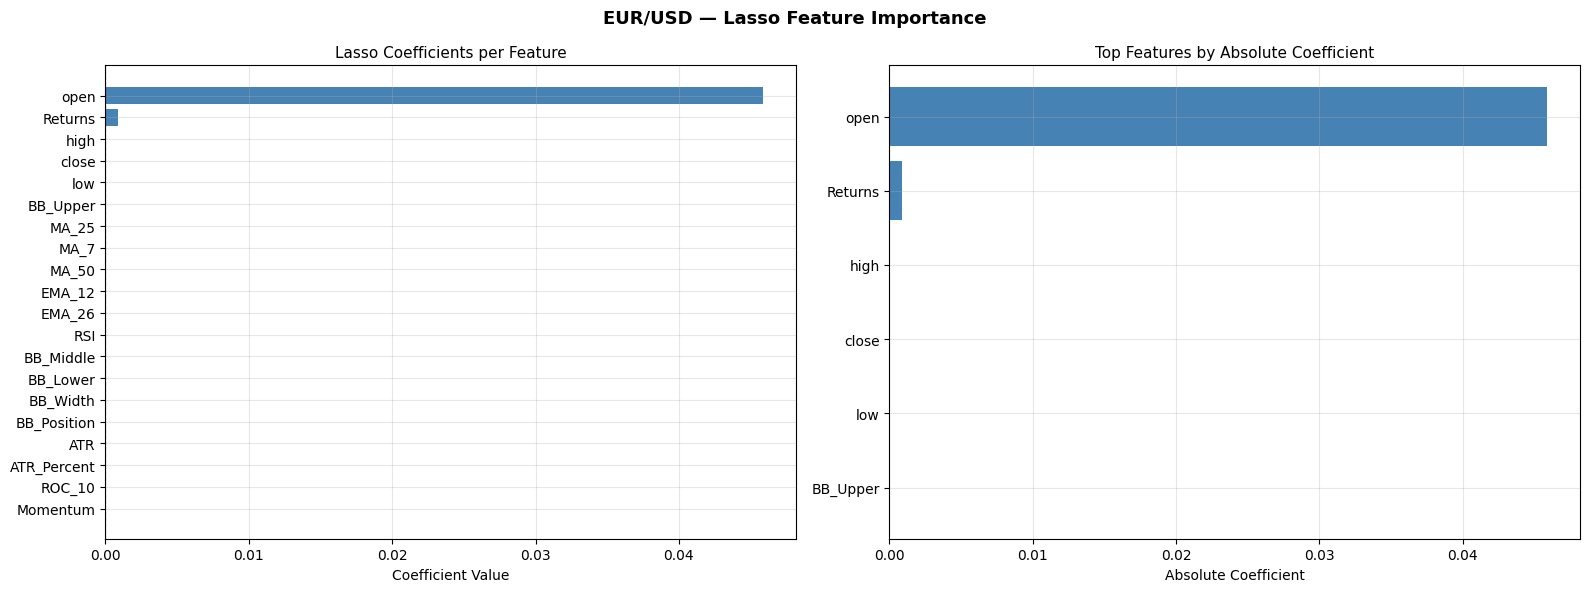


Features carried forward:
['open', 'Returns', 'high', 'close', 'low', 'BB_Upper']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("eurusd_features.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

FEATURE_COLS = [
    "open", "high", "low", "close",
    "Returns", "MA_7", "MA_25", "MA_50",
    "EMA_12", "EMA_26", "RSI",
    "BB_Upper", "BB_Middle", "BB_Lower", "BB_Width", "BB_Position",
    "ATR", "ATR_Percent", "ROC_10", "Momentum"
]

FORECAST_H = 1

df["Target_Close"] = df["close"].shift(-FORECAST_H)
df = df.dropna().reset_index(drop=True)

X        = df[FEATURE_COLS].values
y        = df["Target_Close"].values
X_scaled = StandardScaler().fit_transform(X)

# TimeSeriesSplit preserves temporal order during cross-validation
tscv  = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, max_iter=10000, random_state=42, n_alphas=100)
lasso.fit(X_scaled, y)

print(f"Best alpha : {lasso.alpha_:.6f}")
print(f"R²         : {lasso.score(X_scaled, y):.4f}")

coef_df = pd.DataFrame({
    "Feature":     FEATURE_COLS,
    "Coefficient": lasso.coef_,
    "Abs_Coef":    np.abs(lasso.coef_)
}).sort_values("Abs_Coef", ascending=False).reset_index(drop=True)

print(coef_df.to_string(index=False))

eliminated = coef_df[coef_df["Coefficient"] == 0]["Feature"].tolist()
print(f"\nEliminated : {eliminated}")
print(f"Retained   : {len(coef_df) - len(eliminated)} / {len(FEATURE_COLS)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ["steelblue" if c > 0 else "tomato" if c < 0 else "lightgrey"
          for c in coef_df["Coefficient"]]
axes[0].barh(coef_df["Feature"][::-1], coef_df["Coefficient"][::-1], color=colors[::-1])
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Lasso Coefficients per Feature", fontsize=11)
axes[0].set_xlabel("Coefficient Value")
axes[0].grid(alpha=0.3)

top_n = coef_df[coef_df["Abs_Coef"] > 0].head(15)
axes[1].barh(top_n["Feature"][::-1], top_n["Abs_Coef"][::-1], color="steelblue")
axes[1].set_title("Top Features by Absolute Coefficient", fontsize=11)
axes[1].set_xlabel("Absolute Coefficient")
axes[1].grid(alpha=0.3)

plt.suptitle("EUR/USD — Lasso Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("lasso_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

coef_df.to_csv("lasso_feature_importance.csv", index=False)

top_features = coef_df[coef_df["Abs_Coef"] > 0]["Feature"].tolist()
print(f"\nFeatures carried forward:\n{top_features}")

Loaded rows: 13040
Features (15): ['returns', 'ma_7', 'ma_25', 'ma_50', 'ema_12', 'ema_26', 'rsi', 'bb_upper', 'bb_middle', 'bb_lower', 'bb_width', 'bb_position', 'atr_percent', 'roc_10', 'momentum']
Dropped rows: 5
Split | Train: 9124 | Val: 1955 | Test: 1956
Windowed | Train: (9092, 32, 15) | Val: (1923, 32, 15) | Test: (1924, 32, 15)

Training LSTM...
  RMSE=10.0207 | MAE=7.2166 | R²=0.5214 | DirAcc=0.7349 | AUC=0.8230

Training Deep_LSTM...
  RMSE=9.7493 | MAE=7.0668 | R²=0.5470 | DirAcc=0.7396 | AUC=0.8279

Training GRU...
  RMSE=9.8508 | MAE=7.0485 | R²=0.5375 | DirAcc=0.7401 | AUC=0.8249

Training Bidirectional_LSTM...
  RMSE=10.0740 | MAE=7.4374 | R²=0.5163 | DirAcc=0.7302 | AUC=0.8201

Training CNN_LSTM...
  RMSE=9.6498 | MAE=6.9642 | R²=0.5562 | DirAcc=0.7406 | AUC=0.8252

Training CNN...
  RMSE=9.7768 | MAE=7.0815 | R²=0.5445 | DirAcc=0.7458 | AUC=0.8292

=== Architecture Comparison ===
      Architecture    RMSE    MAE     R²   Corr  Dir Accuracy  Sign AUC
               CN

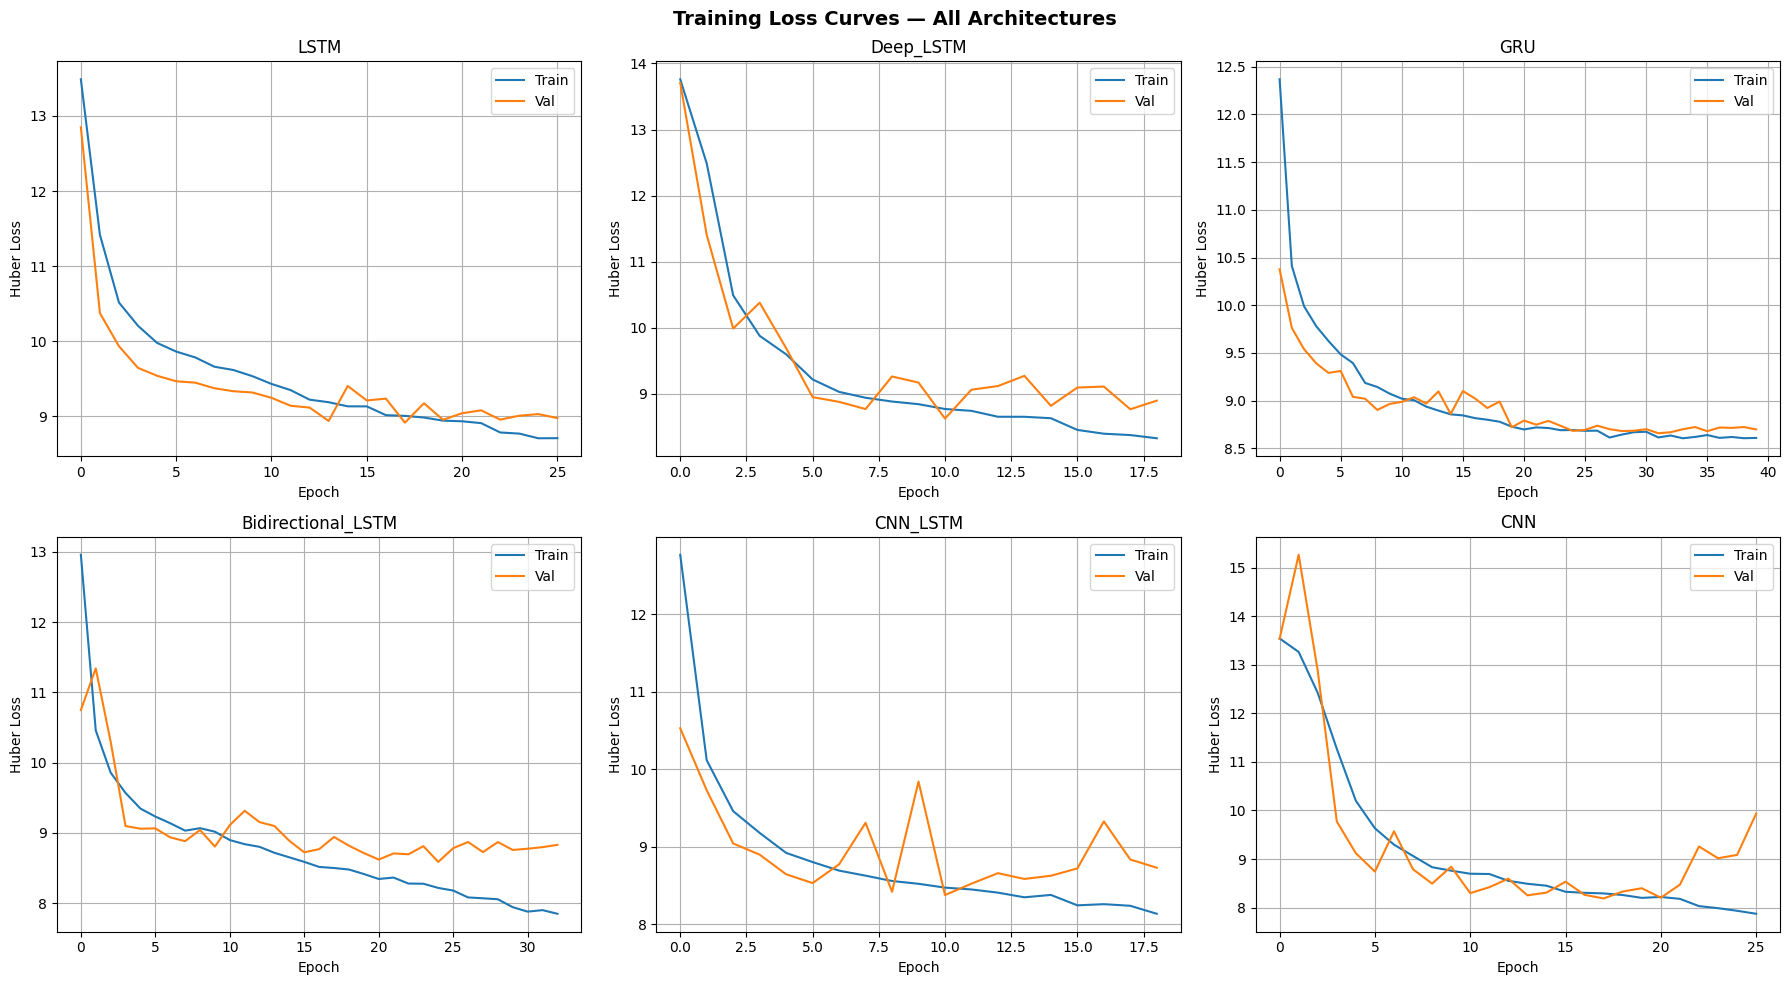

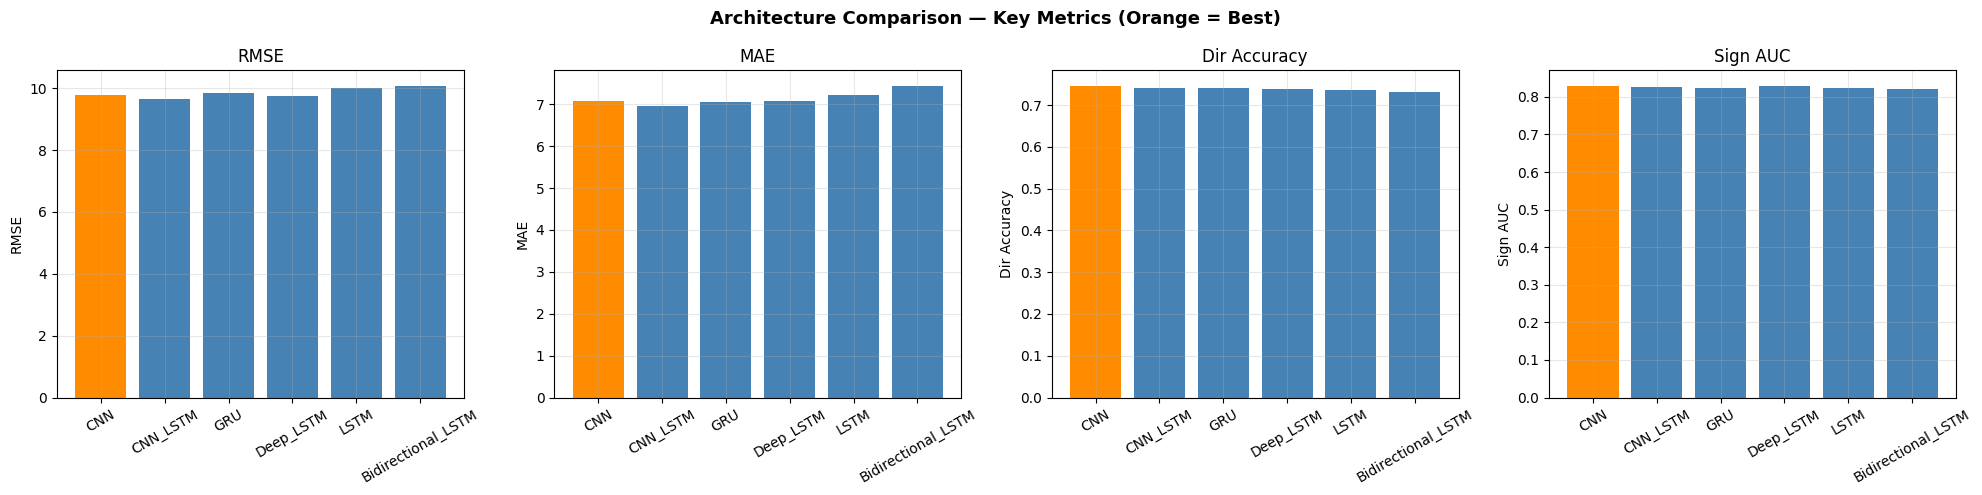


Best model saved: eurusd_t5_CNN_cumulative_seq32.keras

t+5 signal saved:
t5_best_architecture           CNN
t5_predicted_pips           2.4787
t5_true_pips                  -0.0
t5_direction               Bullish
t5_directional_accuracy     0.7458
t5_sign_auc                 0.8292
t5_rmse                     9.7768
t5_r2                       0.5445
t5_confidence                  Low
dtype: object


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D, Flatten, Bidirectional, GlobalAveragePooling1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Add
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, confusion_matrix, accuracy_score
)
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.mixed_precision.set_global_policy("float32")

SEQ_LEN     = 32
BATCH_SIZE  = 64
EPOCHS      = 80
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TARGET_KIND = "cumulative"
Y_SCALE     = 10000.0
L2_LAMBDA   = 1e-3
DROPOUT     = 0.2
LR          = 1e-3

df = pd.read_csv("eurusd_features.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
df = df.set_index("datetime")
df.columns = [c.lower() for c in df.columns]

required_cols = {"open", "high", "low", "close"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"Missing OHLC columns. Need {required_cols}, got {set(df.columns)}")

print("Loaded rows:", len(df))

if "log_ret" not in df.columns:
    df["log_ret"] = np.log(df["close"] / df["close"].shift(1))

def make_t5_targets(df, target_kind="cumulative"):
    s = df["log_ret"]
    if target_kind == "simple":
        y = s.shift(-5)
    elif target_kind == "cumulative":
        y = s.shift(-1).rolling(window=5).sum()
    else:
        raise ValueError("target_kind must be 'simple' or 'cumulative'")
    return y.rename("target")

df["target"] = make_t5_targets(df, TARGET_KIND)

extra_cols = [
    "returns", "ma_7", "ma_25", "ma_50",
    "ema_12", "ema_26", "rsi",
    "bb_upper", "bb_middle", "bb_lower",
    "bb_width", "bb_position",
    "atr_percent", "roc_10", "momentum"
]
FEATURE_COLS = [c for c in extra_cols if c in df.columns]

if len(FEATURE_COLS) == 0:
    raise ValueError("No feature columns found in CSV.")

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

df["sample_weight"] = 1.0
cols_needed = FEATURE_COLS + ["target", "sample_weight"]
df_clean    = df[cols_needed].replace([np.inf, -np.inf], np.nan).dropna().copy()
print(f"Dropped rows: {len(df) - len(df_clean)}")

n       = len(df_clean)
n_train = int(n * TRAIN_SPLIT)
n_val   = int(n * (TRAIN_SPLIT + VAL_SPLIT))

df_train = df_clean.iloc[:n_train]
df_val   = df_clean.iloc[n_train:n_val]
df_test  = df_clean.iloc[n_val:]

print(f"Split | Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

x_scaler    = StandardScaler()
X_train_raw = x_scaler.fit_transform(df_train[FEATURE_COLS])
X_val_raw   = x_scaler.transform(df_val[FEATURE_COLS])
X_test_raw  = x_scaler.transform(df_test[FEATURE_COLS])

y_train = (df_train["target"].values * Y_SCALE).astype(np.float32)
y_val   = (df_val["target"].values   * Y_SCALE).astype(np.float32)
y_test  = (df_test["target"].values  * Y_SCALE).astype(np.float32)

w_train = df_train["sample_weight"].values.astype(np.float32)
w_val   = df_val["sample_weight"].values.astype(np.float32)
w_test  = df_test["sample_weight"].values.astype(np.float32)

def assert_all_finite(name, arr):
    if not np.all(np.isfinite(arr)):
        n_nans = np.sum(~np.isfinite(arr))
        raise ValueError(f"{name} has non-finite values: {n_nans} entries")

assert_all_finite("X_train_raw", X_train_raw)
assert_all_finite("X_val_raw",   X_val_raw)
assert_all_finite("X_test_raw",  X_test_raw)
assert_all_finite("y_train",     y_train)
assert_all_finite("y_val",       y_val)
assert_all_finite("y_test",      y_test)

def create_windows(X, y, w, win=32):
    Xs, ys, ws = [], [], []
    for i in range(win, len(X)):
        Xs.append(X[i-win:i])
        ys.append(y[i])
        ws.append(w[i])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            np.array(ws, dtype=np.float32))

X_train, y_train, w_train = create_windows(X_train_raw, y_train, w_train, SEQ_LEN)
X_val,   y_val,   w_val   = create_windows(X_val_raw,   y_val,   w_val,   SEQ_LEN)
X_test,  y_test,  w_test  = create_windows(X_test_raw,  y_test,  w_test,  SEQ_LEN)

print(f"Windowed | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

input_shape = (X_train.shape[1], X_train.shape[2])


def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape,
             kernel_regularizer=l2(L2_LAMBDA)),
        Dropout(DROPOUT),
        LSTM(32, return_sequences=False, kernel_regularizer=l2(L2_LAMBDA)),
        Dropout(DROPOUT),
        Dense(1, activation="linear")
    ], name="LSTM")
    return model


def build_deep_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape,
             kernel_regularizer=l2(L2_LAMBDA)),
        BatchNormalization(),
        Dropout(DROPOUT),
        LSTM(64, return_sequences=True, kernel_regularizer=l2(L2_LAMBDA)),
        BatchNormalization(),
        Dropout(DROPOUT),
        LSTM(32, return_sequences=False, kernel_regularizer=l2(L2_LAMBDA)),
        Dropout(DROPOUT),
        Dense(16, activation="relu"),
        Dense(1, activation="linear")
    ], name="Deep_LSTM")
    return model


def build_gru(input_shape):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape,
            kernel_regularizer=l2(L2_LAMBDA)),
        Dropout(DROPOUT),
        GRU(32, return_sequences=False, kernel_regularizer=l2(L2_LAMBDA)),
        Dropout(DROPOUT),
        Dense(1, activation="linear")
    ], name="GRU")
    return model


def build_bidirectional_lstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True,
                           kernel_regularizer=l2(L2_LAMBDA)),
                      input_shape=input_shape),
        Dropout(DROPOUT),
        Bidirectional(LSTM(32, return_sequences=False,
                           kernel_regularizer=l2(L2_LAMBDA))),
        Dropout(DROPOUT),
        Dense(16, activation="relu"),
        Dense(1, activation="linear")
    ], name="Bidirectional_LSTM")
    return model


def build_cnn_lstm(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation="relu",
               padding="same", input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, activation="relu", padding="same"),
        LSTM(32, return_sequences=False, kernel_regularizer=l2(L2_LAMBDA)),
        Dropout(DROPOUT),
        Dense(16, activation="relu"),
        Dense(1, activation="linear")
    ], name="CNN_LSTM")
    return model


def build_cnn(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation="relu",
               padding="same", input_shape=input_shape),
        BatchNormalization(),
        Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, activation="relu", padding="same"),
        GlobalAveragePooling1D(),
        Dense(32, activation="relu"),
        Dropout(DROPOUT),
        Dense(1, activation="linear")
    ], name="CNN")
    return model


ARCHITECTURES = {
    "LSTM":                build_lstm(input_shape),
    "Deep_LSTM":           build_deep_lstm(input_shape),
    "GRU":                 build_gru(input_shape),
    "Bidirectional_LSTM":  build_bidirectional_lstm(input_shape),
    "CNN_LSTM":            build_cnn_lstm(input_shape),
    "CNN":                 build_cnn(input_shape),
}

def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )
    return model

def get_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=8,
                      mode="min", restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", patience=4,
                          factor=0.5, mode="min")
    ]

def evaluate_model(model, y_true_arr, y_pred_arr):
    valid  = np.isfinite(y_true_arr) & np.isfinite(y_pred_arr)
    y_t    = y_true_arr[valid]
    y_p    = y_pred_arr[valid]
    rmse   = float(np.sqrt(mean_squared_error(y_t, y_p)))
    mae    = float(mean_absolute_error(y_t, y_p))
    r2     = float(r2_score(y_t, y_p))
    try:
        corr = float(pearsonr(y_t, y_p)[0])
    except Exception:
        corr = np.nan
    true_sign = (y_t > 0).astype(int)
    pred_sign = (y_p > 0).astype(int)
    dir_acc   = float(accuracy_score(true_sign, pred_sign))
    try:
        sign_auc = float(roc_auc_score(true_sign, y_p))
    except Exception:
        sign_auc = np.nan
    return {
        "rmse":     rmse,
        "mae":      mae,
        "r2":       r2,
        "corr":     corr,
        "dir_acc":  dir_acc,
        "sign_auc": sign_auc,
        "y_true":   y_t,
        "y_pred":   y_p,
    }


results     = {}
histories   = {}

for name, model in ARCHITECTURES.items():
    print(f"\nTraining {name}...")
    compile_model(model)
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val, w_val),
        sample_weight=w_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(),
        verbose=0
    )
    p_test     = model.predict(X_test, verbose=0).flatten()
    metrics    = evaluate_model(model, y_test, p_test)
    results[name]   = metrics
    histories[name] = hist
    print(f"  RMSE={metrics['rmse']:.4f} | MAE={metrics['mae']:.4f} | "
          f"R²={metrics['r2']:.4f} | DirAcc={metrics['dir_acc']:.4f} | "
          f"AUC={metrics['sign_auc']:.4f}")


print("\n=== Architecture Comparison ===")
summary_rows = []
for name, m in results.items():
    summary_rows.append({
        "Architecture":        name,
        "RMSE":                round(m["rmse"], 4),
        "MAE":                 round(m["mae"], 4),
        "R²":                  round(m["r2"], 4),
        "Corr":                round(m["corr"], 4),
        "Dir Accuracy":        round(m["dir_acc"], 4),
        "Sign AUC":            round(m["sign_auc"], 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Dir Accuracy", ascending=False)
print(summary_df.to_string(index=False))
summary_df.to_csv("architecture_comparison.csv", index=False)

best_name = summary_df.iloc[0]["Architecture"]
print(f"\nBest architecture by directional accuracy: {best_name}")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, hist) in enumerate(histories.items()):
    axes[i].plot(hist.history.get("loss", []),     label="Train")
    axes[i].plot(hist.history.get("val_loss", []), label="Val")
    axes[i].set_title(f"{name}")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Huber Loss")
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle("Training Loss Curves — All Architectures", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("architecture_loss_curves.png", dpi=150)
plt.show()


metrics_to_plot = ["RMSE", "MAE", "Dir Accuracy", "Sign AUC"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
names = summary_df["Architecture"].tolist()

for i, metric in enumerate(metrics_to_plot):
    vals = summary_df[metric].tolist()
    colors = ["steelblue" if n != best_name else "darkorange" for n in names]
    axes[i].bar(names, vals, color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].grid(alpha=0.3)

plt.suptitle("Architecture Comparison — Key Metrics (Orange = Best)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("architecture_metrics_comparison.png", dpi=150)
plt.show()


best_model  = ARCHITECTURES[best_name]
best_result = results[best_name]

pred_df = pd.DataFrame({
    "y_true_pips": best_result["y_true"],
    "y_pred_pips": best_result["y_pred"],
    "true_sign":   (best_result["y_true"] > 0).astype(int),
    "pred_sign":   (best_result["y_pred"] > 0).astype(int),
})
pred_df.to_csv("t5_predictions.csv", index=False)
best_model.save(f"eurusd_t5_{best_name}_{TARGET_KIND}_seq{SEQ_LEN}.keras")
print(f"\nBest model saved: eurusd_t5_{best_name}_{TARGET_KIND}_seq{SEQ_LEN}.keras")

last_pred  = float(best_result["y_pred"][-1])
last_true  = float(best_result["y_true"][-1])
direction  = "Bullish" if last_pred > 0 else "Bearish"
confidence = "High" if abs(last_pred) > 10 else "Medium" if abs(last_pred) > 5 else "Low"

t5_signal = {
    "t5_best_architecture":      best_name,
    "t5_predicted_pips":         round(last_pred, 4),
    "t5_true_pips":              round(last_true, 4),
    "t5_direction":              direction,
    "t5_directional_accuracy":   round(best_result["dir_acc"], 4),
    "t5_sign_auc":               round(best_result["sign_auc"], 4),
    "t5_rmse":                   round(best_result["rmse"], 4),
    "t5_r2":                     round(best_result["r2"], 4),
    "t5_confidence":             confidence,
}

pd.Series(t5_signal).to_csv("t5_signal.csv", header=False)
print("\nt+5 signal saved:")
print(pd.Series(t5_signal))

#LSTM Model Training and Evaluation

Loaded 13,011 rows | 2024-01-04 05:00:00 to 2026-02-16 23:00:00
Train : 9,107 (2024-01-04 to 2025-06-27)
Val   : 1,951 (2025-06-27 to 2025-10-21)
Test  : 1,952 (2025-10-21 to 2026-02-16)
Train: (9083, 24, 20) | Val: (1927, 24, 20) | Test: (1928, 24, 20)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 128)        │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,553 (545.13 KB)

 Trainable params: 139,105 (543.38 KB)

 Non-trainable params: 448 (1.75 KB)

Training...
Epoch 1/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - loss: 0.3448 - mae: 0.4254 - val_loss: 0.6443 - val_mae: 0.7966 - learning_rate: 0.0010
Epoch 2/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - loss: 0.0773 - mae: 0.2176 - val_loss: 0.3710 - val_mae: 0.6083 - learning_rate: 0.0010
Epoch 3/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0410 - mae: 0.1580 - val_loss: 0.1434 - val_mae: 0.3766 - learning_rate: 0.0010
Epoch 4/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - loss: 0.0259 - mae: 0.1250 - val_loss: 0.0964 - val_mae: 0.3074 - learning_rate: 0.0010
Epoch 5/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0190 - mae: 0.1062 - val_loss: 0.0572 - val_mae: 0.2349 - learning_rate: 0.0010
Epoch 6/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0146 - mae: 0.0936 - val_loss: 0.0445 - val_mae: 0.2068 - learning_rate: 0.0010
Epoch 7/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0123 - mae: 0.0851 - val_loss: 0.0371 - val_mae: 0

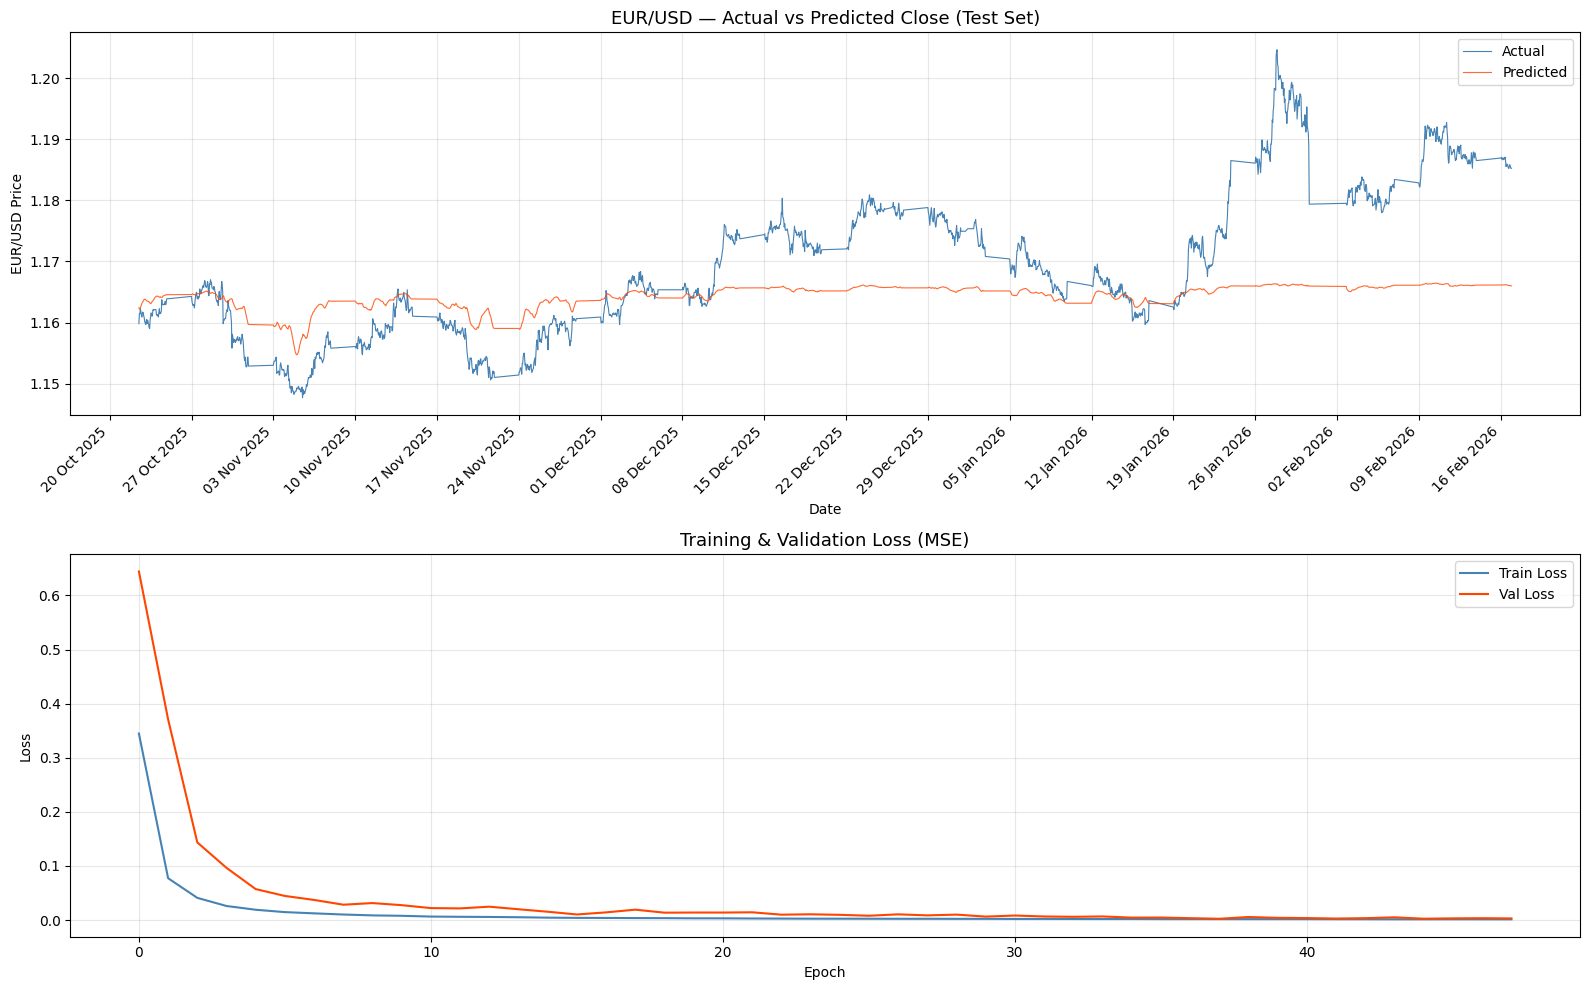

Saved: eurusd_lstm_model.keras, lstm_test_predictions.csv, lstm_results.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

SEQ_LEN     = 24   # hours of history the model looks back on each prediction
FORECAST_H  = 1    # hours ahead we want to predict
BATCH_SIZE  = 64
EPOCHS      = 100
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15

FEATURE_COLS = [
    "open", "high", "low", "close",
    "Returns", "MA_7", "MA_25", "MA_50",
    "EMA_12", "EMA_26", "RSI",
    "BB_Upper", "BB_Middle", "BB_Lower", "BB_Width", "BB_Position",
    "ATR", "ATR_Percent", "ROC_10", "Momentum"
]

df = pd.read_csv("eurusd_features.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
print(f"Loaded {len(df):,} rows | {df['datetime'].min()} to {df['datetime'].max()}")

df["Target_Close"] = df["close"].shift(-FORECAST_H)
df = df.dropna().reset_index(drop=True)

# Split chronologically before fitting the scaler so future prices
# never influence how the training data gets normalised.
n_total = len(df)
n_train = int(n_total * TRAIN_SPLIT)
n_val   = int(n_total * (TRAIN_SPLIT + VAL_SPLIT))

df_train = df.iloc[:n_train].reset_index(drop=True)
df_val   = df.iloc[n_train:n_val].reset_index(drop=True)
df_test  = df.iloc[n_val:].reset_index(drop=True)

print(f"Train : {len(df_train):,} ({df_train['datetime'].min().date()} to {df_train['datetime'].max().date()})")
print(f"Val   : {len(df_val):,} ({df_val['datetime'].min().date()} to {df_val['datetime'].max().date()})")
print(f"Test  : {len(df_test):,} ({df_test['datetime'].min().date()} to {df_test['datetime'].max().date()})")

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_raw  = scaler_X.fit_transform(df_train[FEATURE_COLS].values)
X_val_raw    = scaler_X.transform(df_val[FEATURE_COLS].values)
X_test_raw   = scaler_X.transform(df_test[FEATURE_COLS].values)

yp_train_raw = scaler_y.fit_transform(df_train["Target_Close"].values.reshape(-1, 1))
yp_val_raw   = scaler_y.transform(df_val["Target_Close"].values.reshape(-1, 1))
yp_test_raw  = scaler_y.transform(df_test["Target_Close"].values.reshape(-1, 1))

def build_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train, y_train = build_sequences(X_train_raw, yp_train_raw, SEQ_LEN)
X_val,   y_val   = build_sequences(X_val_raw,   yp_val_raw,   SEQ_LEN)
X_test,  y_test  = build_sequences(X_test_raw,  yp_test_raw,  SEQ_LEN)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, len(FEATURE_COLS))),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1, activation="linear")
])

model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"\nRMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"MAPE : {mape:.4f}%")

test_dates = df_test["datetime"].iloc[SEQ_LEN:].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(test_dates, y_true, label="Actual",    color="steelblue", linewidth=0.8)
axes[0].plot(test_dates, y_pred, label="Predicted", color="orangered", linewidth=0.8, alpha=0.8)
axes[0].set_title("EUR/USD — Actual vs Predicted Close (Test Set)", fontsize=13)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("EUR/USD Price")
axes[0].xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0, interval=1))
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train Loss", color="steelblue")
axes[1].plot(history.history["val_loss"], label="Val Loss",   color="orangered")
axes[1].set_title("Training & Validation Loss (MSE)", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("lstm_results.png", dpi=150)
plt.show()

model.save("eurusd_lstm_model.keras")

pd.DataFrame({
    "Actual_Close":    y_true,
    "Predicted_Close": y_pred,
    "Error":           y_pred - y_true
}).to_csv("lstm_test_predictions.csv", index=False)

print("Saved: eurusd_lstm_model.keras, lstm_test_predictions.csv, lstm_results.png")

#Eigen vector and value analysis

Fetching 2025 data from Twelve Data...
  EUR/USD
  GBP/USD
  USD/JPY
  USD/CHF
  AUD/USD
  USD/CAD

Fetching 2026 data from Yahoo Finance...
  EUR/USD
  GBP/USD
  USD/JPY
  USD/CHF
  AUD/USD
  USD/CAD

Merged price matrix : (6844, 6)
Date range          : 2025-01-02 09:00:00 to 2026-02-13 22:00:00


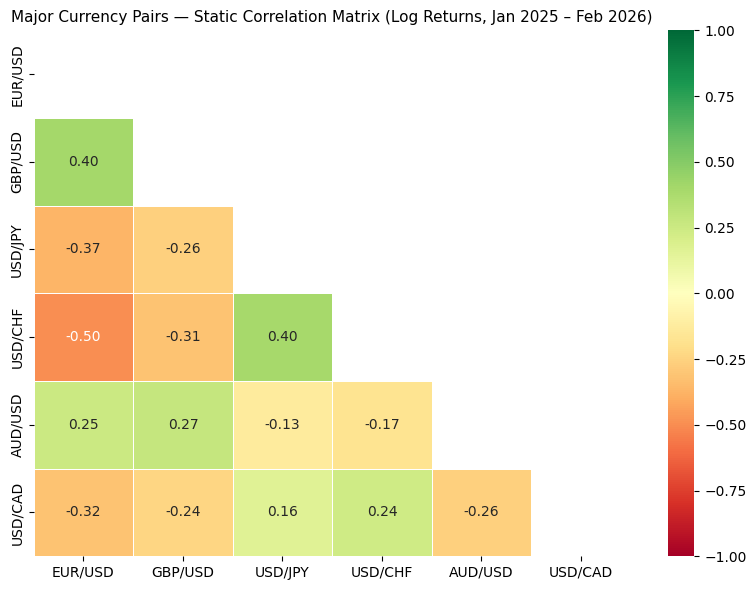

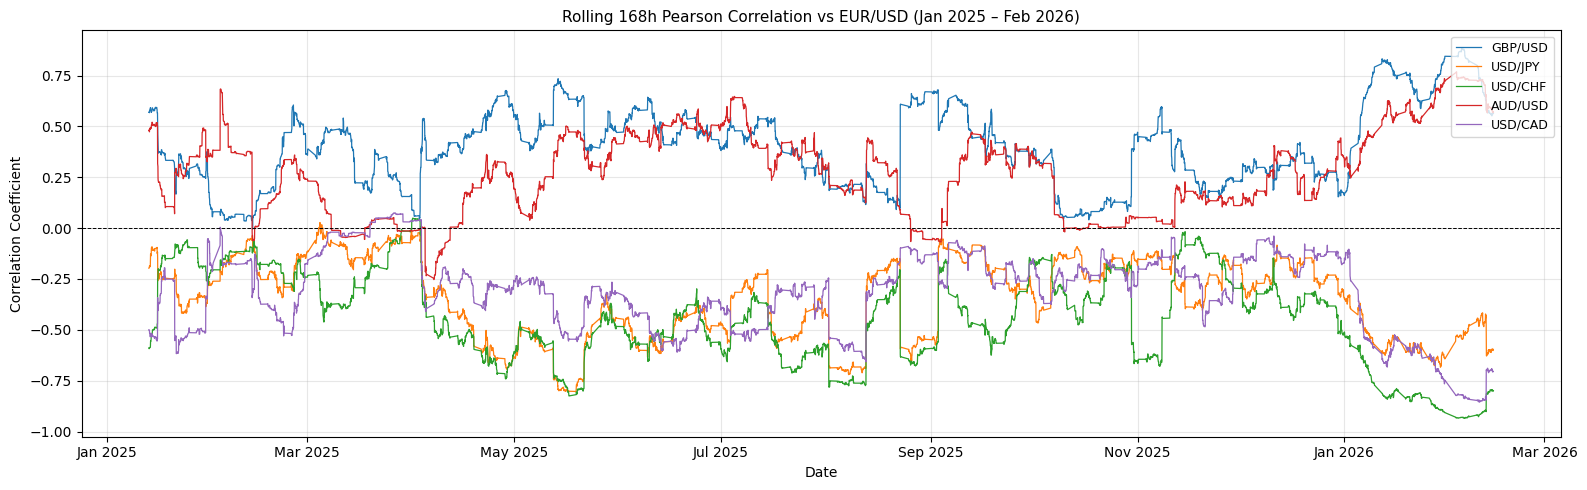


Full Period (Jan 2025 – Feb 2026)
Component      Eigenvalue    Var Explained   Cumulative
--------------------------------------------------------
PC1                2.4675           41.12%       41.12%
PC2                0.9961           16.60%       57.73%
PC3                0.7568           12.61%       70.34%
PC4                0.6860           11.43%       81.77%
PC5                0.6098           10.16%       91.94%
PC6                0.4838            8.06%      100.00%

Recent 90 Days
Component      Eigenvalue    Var Explained   Cumulative
--------------------------------------------------------
PC1                2.9971           49.95%       49.95%
PC2                0.8978           14.96%       64.92%
PC3                0.6263           10.44%       75.35%
PC4                0.6228           10.38%       85.73%
PC5                0.4649            7.75%       93.48%
PC6                0.3910            6.52%      100.00%


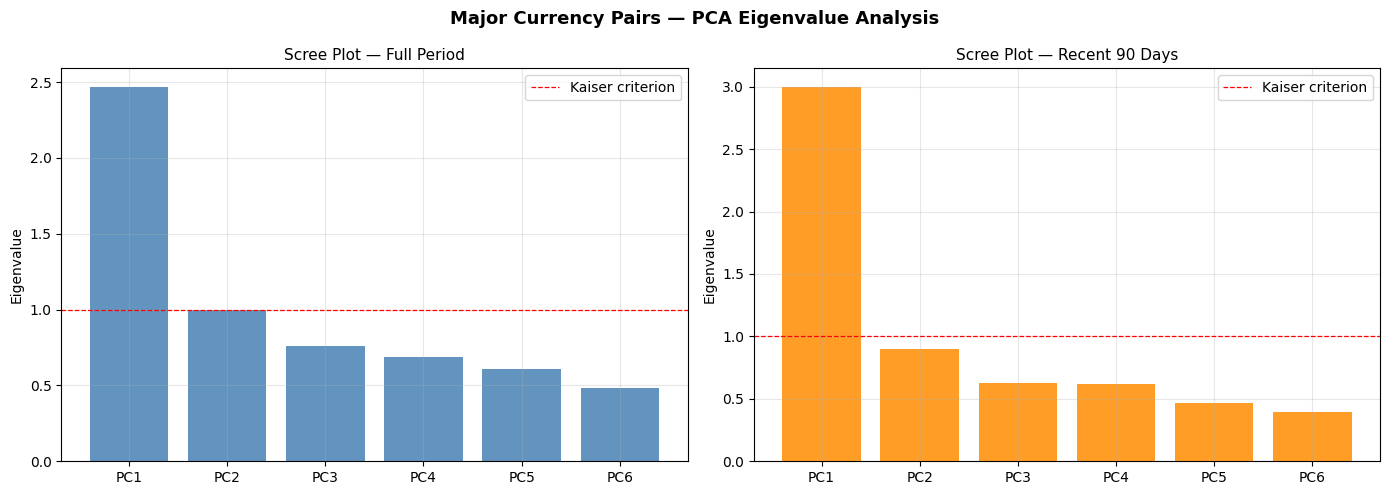


PC1 Loadings (recent 90 days):
EUR/USD    0.461609
USD/CHF    0.451214
USD/CAD    0.412313
GBP/USD    0.406364
AUD/USD    0.377462
USD/JPY    0.325134


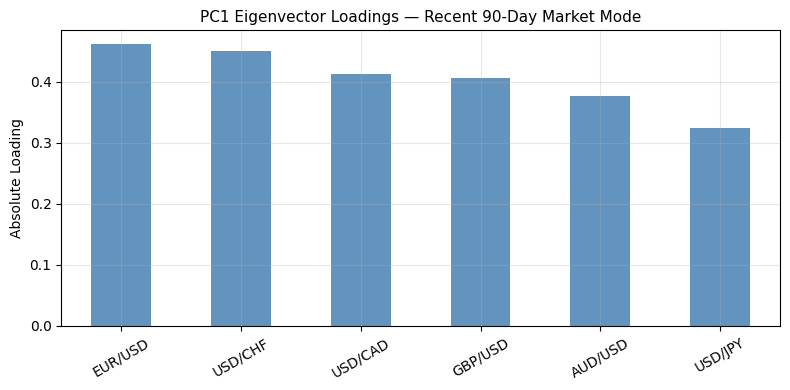


Correlation signal:
dominant_correlated_pair    USD/CHF
correlation_value           -0.8841
pc1_variance_explained        49.95
market_concentration         0.4995
dtype: object


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import requests
import time
import warnings
warnings.filterwarnings("ignore")

ROLLING_WINDOW = 168
TD_API_KEY     = "fadaafd3053d486393e5bcd3e348d194"

PAIRS = {
    "EUR/USD": {"td": "EUR/USD", "yf": "EURUSD=X"},
    "GBP/USD": {"td": "GBP/USD", "yf": "GBPUSD=X"},
    "USD/JPY": {"td": "USD/JPY", "yf": "JPY=X"},
    "USD/CHF": {"td": "USD/CHF", "yf": "CHF=X"},
    "AUD/USD": {"td": "AUD/USD", "yf": "AUDUSD=X"},
    "USD/CAD": {"td": "USD/CAD", "yf": "CAD=X"},
}

TD_CHUNKS = [
    ("2025-01-01 00:00:00", "2025-04-01 00:00:00"),
    ("2025-04-01 00:00:00", "2025-07-01 00:00:00"),
    ("2025-07-01 00:00:00", "2025-10-01 00:00:00"),
    ("2025-10-01 00:00:00", "2026-01-01 00:00:00"),
]


def fetch_td_pair(symbol):
    periods = []
    for chunk_start, chunk_end in TD_CHUNKS:
        params = {
            "symbol":     symbol,
            "interval":   "1h",
            "start_date": chunk_start,
            "end_date":   chunk_end,
            "outputsize": 5000,
            "apikey":     TD_API_KEY,
            "format":     "JSON",
        }
        r    = requests.get("https://api.twelvedata.com/time_series", params=params, timeout=30)
        data = r.json()
        if "values" not in data:
            print(f"  {symbol} {chunk_start}: {data.get('message', 'no values')}")
            time.sleep(15)
            continue
        chunk = pd.DataFrame(data["values"])
        chunk["datetime"] = pd.to_datetime(chunk["datetime"])
        chunk = chunk.set_index("datetime").sort_index()[["close"]].astype(float)
        periods.append(chunk)
        time.sleep(15)

    if not periods:
        return pd.Series(dtype=float, name=symbol)
    result = pd.concat(periods).drop_duplicates().sort_index()
    return result["close"].rename(symbol)


def fetch_yf_pair(ticker, name):
    raw = yf.download(ticker, start="2026-01-01", end="2026-02-16",
                      interval="1h", progress=False)
    if raw.empty:
        return pd.Series(dtype=float, name=name)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.droplevel(1)
    s = raw["Close"].copy()
    s.index = pd.to_datetime(s.index, utc=True).tz_localize(None)
    s.name = name
    return s


print("Fetching 2025 data from Twelve Data...")
td_closes = {}
for name, tickers in PAIRS.items():
    print(f"  {name}")
    td_closes[name] = fetch_td_pair(tickers["td"])

print("\nFetching 2026 data from Yahoo Finance...")
yf_closes = {}
for name, tickers in PAIRS.items():
    print(f"  {name}")
    yf_closes[name] = fetch_yf_pair(tickers["yf"], name)

merged = {}
for name in PAIRS:
    td_s = td_closes.get(name, pd.Series(dtype=float))
    yf_s = yf_closes.get(name, pd.Series(dtype=float))

    if not td_s.empty:
        td_s.index = pd.to_datetime(td_s.index).tz_localize(None)
    if not yf_s.empty:
        yf_s.index = pd.to_datetime(yf_s.index).tz_localize(None)

    combined = pd.concat([td_s, yf_s]).sort_index()
    combined = combined[~combined.index.duplicated(keep="last")]
    merged[name] = combined

price_df = pd.DataFrame(merged).sort_index().ffill().dropna()

print(f"\nMerged price matrix : {price_df.shape}")
print(f"Date range          : {price_df.index[0]} to {price_df.index[-1]}")

price_df.to_csv("multi_pair_closes.csv")

returns_df = np.log(price_df / price_df.shift(1)).dropna()

static_corr = returns_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(static_corr, dtype=bool))
sns.heatmap(
    static_corr, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, mask=mask
)
ax.set_title("Major Currency Pairs — Static Correlation Matrix (Log Returns, Jan 2025 – Feb 2026)", fontsize=11)
plt.tight_layout()
plt.savefig("static_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

eurusd_returns = returns_df["EUR/USD"]
rolling_corrs  = pd.DataFrame(index=returns_df.index)

for col in returns_df.columns:
    if col != "EUR/USD":
        rolling_corrs[col] = eurusd_returns.rolling(ROLLING_WINDOW).corr(returns_df[col])

rolling_corrs = rolling_corrs.dropna()

fig, ax = plt.subplots(figsize=(16, 5))
for col in rolling_corrs.columns:
    ax.plot(rolling_corrs.index, rolling_corrs[col], label=col, linewidth=0.9)
ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_title(f"Rolling {ROLLING_WINDOW}h Pearson Correlation vs EUR/USD (Jan 2025 – Feb 2026)", fontsize=11)
ax.set_xlabel("Date")
ax.set_ylabel("Correlation Coefficient")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rolling_correlation_eurusd.png", dpi=150, bbox_inches="tight")
plt.show()


def pca_from_corr(corr_matrix, label=""):
    eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix.values)
    idx          = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    explained    = eigenvalues / eigenvalues.sum() * 100

    print(f"\n{label}")
    print(f"{'Component':<12} {'Eigenvalue':>12} {'Var Explained':>16} {'Cumulative':>12}")
    print("-" * 56)
    cumulative = 0.0
    for i, (ev, pct) in enumerate(zip(eigenvalues, explained)):
        cumulative += pct
        print(f"PC{i+1:<10} {ev:>12.4f} {pct:>15.2f}% {cumulative:>11.2f}%")

    return eigenvalues, eigenvectors, explained


eigenvalues_full, eigenvectors_full, explained_full = pca_from_corr(
    static_corr, label="Full Period (Jan 2025 – Feb 2026)"
)

recent_window          = 90 * 24
recent_returns         = returns_df.iloc[-recent_window:] if len(returns_df) > recent_window else returns_df
recent_corr            = recent_returns.corr()
eigenvalues_recent, eigenvectors_recent, explained_recent = pca_from_corr(
    recent_corr, label="Recent 90 Days"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_ticks = [f"PC{i+1}" for i in range(len(eigenvalues_full))]

axes[0].bar(x_ticks, eigenvalues_full, color="steelblue", alpha=0.85)
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=0.9, label="Kaiser criterion")
axes[0].set_title("Scree Plot — Full Period", fontsize=11)
axes[0].set_ylabel("Eigenvalue")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(x_ticks, eigenvalues_recent, color="darkorange", alpha=0.85)
axes[1].axhline(1.0, color="red", linestyle="--", linewidth=0.9, label="Kaiser criterion")
axes[1].set_title("Scree Plot — Recent 90 Days", fontsize=11)
axes[1].set_ylabel("Eigenvalue")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Major Currency Pairs — PCA Eigenvalue Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eigenvalue_scree_plots.png", dpi=150, bbox_inches="tight")
plt.show()

pc1_loadings = pd.Series(
    np.abs(eigenvectors_recent[:, 0]),
    index=recent_corr.columns
).sort_values(ascending=False)

print("\nPC1 Loadings (recent 90 days):")
print(pc1_loadings.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
pc1_loadings.plot(kind="bar", ax=ax, color="steelblue", alpha=0.85)
ax.set_title("PC1 Eigenvector Loadings — Recent 90-Day Market Mode", fontsize=11)
ax.set_ylabel("Absolute Loading")
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("pc1_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

rolling_corrs.to_csv("rolling_correlations.csv")
pd.DataFrame(recent_corr).to_csv("recent_correlation_matrix.csv")

last_168h_corr = rolling_corrs.iloc[-ROLLING_WINDOW:].mean()
dominant_pair  = last_168h_corr.abs().idxmax()
dominant_corr  = last_168h_corr[dominant_pair]
market_conc    = eigenvalues_recent[0] / eigenvalues_recent.sum()

correlation_signal = {
    "dominant_correlated_pair": dominant_pair,
    "correlation_value":        round(float(dominant_corr), 4),
    "pc1_variance_explained":   round(float(explained_recent[0]), 2),
    "market_concentration":     round(float(market_conc), 4),
}

pd.Series(correlation_signal).to_csv("correlation_signal.csv", header=False)
print("\nCorrelation signal:")
print(pd.Series(correlation_signal))

#Anomaly detection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

ZSCORE_THRESHOLD = 3.0
IF_CONTAMINATION = 0.01
IF_N_ESTIMATORS  = 200
RANDOM_STATE     = 42

FEATURE_COLS = [
    "open", "high", "low", "close",
    "Returns", "MA_7", "MA_25", "MA_50",
    "EMA_12", "EMA_26", "RSI",
    "BB_Upper", "BB_Middle", "BB_Lower", "BB_Width", "BB_Position",
    "ATR", "ATR_Percent", "ROC_10", "Momentum"
]

df = pd.read_csv("eurusd_features.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
print(f"Loaded {len(df):,} rows")

df["zscore_returns"] = (df["Returns"] - df["Returns"].mean()) / df["Returns"].std()
df["anomaly_zscore"] = (df["zscore_returns"].abs() > ZSCORE_THRESHOLD).astype(int)

n_zscore = df["anomaly_zscore"].sum()
print(f"Z-score anomalies : {n_zscore} ({n_zscore / len(df) * 100:.2f}%)")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURE_COLS].fillna(0))

iso_forest = IsolationForest(
    n_estimators=IF_N_ESTIMATORS,
    contamination=IF_CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
df["if_raw"]     = iso_forest.fit_predict(X_scaled)
df["anomaly_if"] = (df["if_raw"] == -1).astype(int)
df["if_score"]   = iso_forest.score_samples(X_scaled)

n_if = df["anomaly_if"].sum()
print(f"Isolation Forest anomalies : {n_if} ({n_if / len(df) * 100:.2f}%)")

df["anomaly_combined"] = ((df["anomaly_zscore"] == 1) | (df["anomaly_if"] == 1)).astype(int)
n_combined = df["anomaly_combined"].sum()
print(f"Combined anomalies         : {n_combined} ({n_combined / len(df) * 100:.2f}%)")

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

anomaly_mask = df["anomaly_combined"] == 1
axes[0].plot(df["datetime"], df["close"], color="steelblue", linewidth=0.7, label="EUR/USD Close")
axes[0].scatter(df.loc[anomaly_mask, "datetime"], df.loc[anomaly_mask, "close"],
                color="red", s=12, zorder=5, label="Anomaly")
axes[0].set_title("EUR/USD Close Price with Detected Anomalies", fontsize=11)
axes[0].set_ylabel("Price")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(df["datetime"], df["zscore_returns"], color="grey", linewidth=0.6, label="Z-score (Returns)")
axes[1].axhline( ZSCORE_THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(-ZSCORE_THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axes[1].set_title(f"Hourly Returns Z-score (threshold = {ZSCORE_THRESHOLD})", fontsize=11)
axes[1].set_ylabel("Z-score")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

axes[2].plot(df["datetime"], df["if_score"], color="darkorange", linewidth=0.6, label="IF Anomaly Score")
axes[2].scatter(df.loc[df["anomaly_if"] == 1, "datetime"],
                df.loc[df["anomaly_if"] == 1, "if_score"],
                color="red", s=12, zorder=5)
axes[2].set_title("Isolation Forest Anomaly Score (lower = more anomalous)", fontsize=11)
axes[2].set_ylabel("Score")
axes[2].set_xlabel("Date")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.suptitle("EUR/USD Anomaly Detection — Z-score and Isolation Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()

df_out = df[["datetime", "close", "Returns", "zscore_returns",
             "anomaly_zscore", "anomaly_if", "if_score", "anomaly_combined"]]
df_out.to_csv("eurusd_anomaly_flags.csv", index=False)

recent_24h  = df.tail(24)
anomaly_signal = {
    "anomaly_in_last_24h":   int(recent_24h["anomaly_combined"].any()),
    "max_zscore_last_24h":   round(float(recent_24h["zscore_returns"].abs().max()), 4),
    "min_if_score_last_24h": round(float(recent_24h["if_score"].min()), 4),
    "risk_flag":             "HIGH" if int(recent_24h["anomaly_combined"].any()) else "NORMAL",
}

pd.Series(anomaly_signal).to_csv("anomaly_signal.csv", header=False)
print("\nAnomaly signal:")
print(pd.Series(anomaly_signal))

Loaded 13,011 rows
Z-score anomalies : 218 (1.68%)
Isolation Forest anomalies : 131 (1.01%)
Combined anomalies         : 318 (2.44%)


#News sentiments

In [ ]:
import pandas as pd
import requests
import json
import re
import time
from google.colab import files, userdata
import warnings
warnings.filterwarnings("ignore")

OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")
MODEL              = "google/gemini-2.5-flash"

# ── Upload your CSV ───────────────────────────────────────────────────────────
print("Upload your news_sentiment_articles.csv file...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

news_df = pd.read_csv(filename)
print(f"\nLoaded {len(news_df)} articles from {filename}")
print(news_df[["published_at", "source", "title"]].to_string())
print()

# ── Score every article ───────────────────────────────────────────────────────
def score_article(title, description, content, idx, total):
    body = content if len(str(content)) > len(str(description)) else description
    body = str(body).strip() if pd.notna(body) else ""

    text = (
        f"HEADLINE:\n{str(title)}\n\n"
        f"ARTICLE BODY:\n{body}"
    )

    payload = {
        "model":      MODEL,
        "max_tokens": 50,
        "messages": [
            {
                "role": "system",
                "content": (
                    "You are a forex sentiment analyst specialising in EUR/USD. "
                    "Read the HEADLINE and ARTICLE BODY carefully. "
                    "Classify sentiment toward EUR/USD: Bullish, Bearish, or Neutral. "
                    "Bullish = EUR likely rises vs USD (weak US data, Fed dovish, ECB hawkish). "
                    "Bearish = EUR likely falls vs USD (strong US data, Fed hawkish, ECB dovish). "
                    "Neutral = no clear implication for EUR/USD. "
                    "Score: Bullish 0.1 to 1.0 | Bearish -1.0 to -0.1 | Neutral 0.0. "
                    "Unrelated articles = Neutral 0.0. "
                    "JSON only. No thinking tags. No explanation. "
                    'Format: {"label":"Neutral","score":0.0}'
                ),
            },
            {"role": "user", "content": text},
        ],
    }

    try:
        r = requests.post(
            url="https://openrouter.ai/api/v1/chat/completions",
            headers={
                "Authorization": f"Bearer {OPENROUTER_API_KEY}",
                "Content-Type":  "application/json",
            },
            data=json.dumps(payload),
            timeout=60,
        )

        if r.status_code == 402:
            print(f"  [{idx}/{total}] 402 — out of credits at openrouter.ai/credits")
            return "Neutral", 0.0

        if r.status_code != 200:
            print(f"  [{idx}/{total}] HTTP {r.status_code}: {r.text[:200]}")
            return "Neutral", 0.0

        result = r.json()

        if "choices" not in result:
            print(f"  [{idx}/{total}] Bad response: {str(result)[:200]}")
            return "Neutral", 0.0

        raw   = result["choices"][0]["message"]["content"].strip()
        print(f"  [{idx}/{total}] RAW: {raw[:150]}")   # debug — shows exactly what Gemini returns

        clean = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
        clean = clean.replace("```json", "").replace("```", "").strip()

        match = re.search(r'\{.*?\}', clean, re.DOTALL)
        if not match:
            print(f"  [{idx}/{total}] No JSON — raw: {clean[:80]}")
            return "Neutral", 0.0

        parsed = json.loads(match.group())
        label  = parsed.get("label", "Neutral")
        score  = float(parsed.get("score", 0.0))
        return label, score

    except json.JSONDecodeError as e:
        print(f"  [{idx}/{total}] JSON error: {e} | {clean[:80]}")
        return "Neutral", 0.0
    except requests.exceptions.Timeout:
        print(f"  [{idx}/{total}] Timed out")
        return "Neutral", 0.0
    except Exception as e:
        print(f"  [{idx}/{total}] {type(e).__name__}: {e}")
        return "Neutral", 0.0


labels, scores = [], []
total = len(news_df)

for i, row in news_df.iterrows():
    label, score = score_article(
        row.get("title", ""),
        row.get("description", ""),
        row.get("content", ""),
        i + 1,
        total,
    )
    print(f"  [{i+1}/{total}] {label:8} {score:+.2f}  {str(row.get('title',''))[:65]}")
    labels.append(label)
    scores.append(score)
    time.sleep(1.0)

# ── Write scores back ─────────────────────────────────────────────────────────
news_df["sentiment_label"] = labels
news_df["sentiment_score"] = scores

OUT_CSV = "news_sentiment_articles_scored.csv"
news_df.to_csv(OUT_CSV, index=False)
print(f"\nSaved scored articles to {OUT_CSV}")

# ── Aggregate ─────────────────────────────────────────────────────────────────
avg_score   = news_df["sentiment_score"].mean()
bullish_pct = (news_df["sentiment_label"] == "Bullish").sum() / len(news_df) * 100
bearish_pct = (news_df["sentiment_label"] == "Bearish").sum() / len(news_df) * 100
agg_label   = "Bullish" if avg_score >= 0.1 else "Bearish" if avg_score <= -0.1 else "Neutral"

sentiment_signal = {
    "avg_sentiment_score": round(float(avg_score), 4),
    "sentiment_label":     agg_label,
    "article_count":       total,
    "bullish_pct":         round(bullish_pct, 2),
    "bearish_pct":         round(bearish_pct, 2),
    "sample_headlines":    " | ".join(news_df["title"].dropna().tail(5).tolist()),
}
pd.Series(sentiment_signal).to_csv("sentiment_signal.csv", header=False)

print(f"\n--- Sentiment summary ({total} articles) ---")
print(f"Aggregate  : {avg_score:.4f} ({agg_label})")
print(f"Bullish    : {bullish_pct:.1f}%")
print(f"Bearish    : {bearish_pct:.1f}%")
print(pd.Series(sentiment_signal))

# ── Download both files ───────────────────────────────────────────────────────
files.download(OUT_CSV)
files.download("sentiment_signal.csv")
print("\nBoth files downloaded.")

Upload your news_sentiment_articles.csv file...


Saving news_sentiment_articles.csv to news_sentiment_articles (6).csv

Loaded 98 articles from news_sentiment_articles (6).csv
                 published_at               source                                                                                                                                                                                                                                                       title
0   2026-02-16 14:09:07+00:00              Fortune                                                                                                                  Kevin Warsh is poised to lead the Fed with none of the gravitas Greenspan had but plenty of baggage from Trump, former Powell adviser says
1   2026-02-16 14:42:09+00:00      Crypto Briefing                                                                                                                                                                                    Kevin Warsh’s Fed chair nomination ad

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Both files downloaded.


#section 10

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

PREDICTION_TIMESTAMP = pd.Timestamp("2026-02-17 09:00:00", tz="UTC")
FORECAST_H           = 1
SEQ_LEN              = 24

FEATURE_COLS = [
    "open", "high", "low", "close",
    "Returns", "MA_7", "MA_25", "MA_50",
    "EMA_12", "EMA_26", "RSI",
    "BB_Upper", "BB_Middle", "BB_Lower", "BB_Width", "BB_Position",
    "ATR", "ATR_Percent", "ROC_10", "Momentum"
]

df = pd.read_csv("eurusd_features.csv", parse_dates=["datetime"])
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = df.sort_values("datetime").reset_index(drop=True)

model = tf.keras.models.load_model("eurusd_lstm_model.keras")
print(f"Model loaded.")
print(f"Dataset   : {len(df):,} rows | {df['datetime'].min()} to {df['datetime'].max()}")

history = df[df["datetime"] < PREDICTION_TIMESTAMP].copy()

if len(history) == 0:
    last_ts  = df["datetime"].max()
    history  = df[df["datetime"] < last_ts].copy()
    PREDICTION_TIMESTAMP = last_ts
    print(f"Timestamp not found — using latest available: {PREDICTION_TIMESTAMP}")

print(f"History rows : {len(history)}")
print(f"History end  : {history['datetime'].iloc[-1]}")

truth_row = df[df["datetime"] >= PREDICTION_TIMESTAMP].head(FORECAST_H)
if not truth_row.empty:
    ground_truth_close = float(truth_row["close"].iloc[-1])
    ground_truth_time  = truth_row["datetime"].iloc[-1]
    print(f"Ground truth : {ground_truth_close:.5f} at {ground_truth_time}")
else:
    ground_truth_close = None
    print("Ground truth not available.")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_history = scaler_X.fit_transform(history[FEATURE_COLS].values)
scaler_y.fit(history["close"].values.reshape(-1, 1))

if len(X_history) < SEQ_LEN:
    raise ValueError(f"Not enough history: {len(X_history)} rows, need {SEQ_LEN}.")

X_input              = X_history[-SEQ_LEN:].reshape(1, SEQ_LEN, len(FEATURE_COLS))
y_pred_scaled        = model.predict(X_input, verbose=0)
lstm_predicted_close = float(scaler_y.inverse_transform(y_pred_scaled)[0, 0])
current_close        = float(history["close"].iloc[-1])
lstm_direction       = "Bullish" if lstm_predicted_close > current_close else "Bearish"
lstm_pct_move        = (lstm_predicted_close - current_close) / current_close * 100

print(f"\nCurrent close : {current_close:.5f}")
print(f"Predicted +1h : {lstm_predicted_close:.5f}")
print(f"Direction     : {lstm_direction} ({lstm_pct_move:+.4f}%)")


def load_signal(path):
    try:
        return pd.read_csv(path, index_col=0, header=None).squeeze().to_dict()
    except FileNotFoundError:
        print(f"Warning: {path} not found — using default neutral values.")
        return {}


corr_signal      = load_signal("correlation_signal.csv")
anomaly_signal   = load_signal("anomaly_signal.csv")
sentiment_signal = load_signal("sentiment_signal.csv")

score           = 50
sentiment_label = str(sentiment_signal.get("sentiment_label", "Neutral")).lower()
pc1_var         = float(corr_signal.get("pc1_variance_explained", 50))
anomaly_flag    = int(anomaly_signal.get("anomaly_in_last_24h", 0))
lstm_bullish    = lstm_direction == "Bullish"

if anomaly_flag:
    score -= 30
else:
    score += 20

if pc1_var > 60:
    score -= 10
else:
    score += 10

if (lstm_bullish and "bull" in sentiment_label) or (not lstm_bullish and "bear" in sentiment_label):
    score += 15
elif (lstm_bullish and "bear" in sentiment_label) or (not lstm_bullish and "bull" in sentiment_label):
    score -= 15

score            = max(0, min(100, score))
confidence_label = "High" if score >= 70 else "Medium" if score >= 45 else "Low"

print(f"\nConfidence : {score}/100 ({confidence_label})")

if ground_truth_close is not None:
    actual_direction  = "Bullish" if ground_truth_close > current_close else "Bearish"
    direction_correct = lstm_direction == actual_direction
    error_pips        = abs(lstm_predicted_close - ground_truth_close) * 10000
    print(f"Actual close      : {ground_truth_close:.5f}")
    print(f"Direction correct : {direction_correct}")
    print(f"Error (pips)      : {error_pips:.1f}")

plot_window = history.tail(72)
fig, ax     = plt.subplots(figsize=(16, 5))

ax.plot(plot_window["datetime"], plot_window["close"],
        color="steelblue", linewidth=1.0, label="Historical Close")
ax.axvline(PREDICTION_TIMESTAMP, color="grey", linestyle="--",
           linewidth=0.9, label="Prediction point")

pred_time = PREDICTION_TIMESTAMP + pd.Timedelta(hours=FORECAST_H)
ax.scatter([pred_time], [lstm_predicted_close],
           color="darkorange", s=80, zorder=6,
           label=f"Predicted: {lstm_predicted_close:.5f}")

if ground_truth_close is not None:
    ax.scatter([ground_truth_time], [ground_truth_close],
               color="green", marker="D", s=80, zorder=6,
               label=f"Actual: {ground_truth_close:.5f}")

ax.set_title(
    f"EUR/USD Simulated Next-Hour Prediction | {PREDICTION_TIMESTAMP} | "
    f"{lstm_direction} | Confidence: {confidence_label} ({score}/100)",
    fontsize=11
)
ax.set_xlabel("Datetime")
ax.set_ylabel("EUR/USD Price")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("signal_aggregation_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

prediction_record = {
    "prediction_timestamp":   str(PREDICTION_TIMESTAMP),
    "current_close":          round(current_close, 5),
    "lstm_predicted_close":   round(lstm_predicted_close, 5),
    "lstm_direction":         lstm_direction,
    "lstm_pct_move":          round(lstm_pct_move, 4),
    "sentiment_label":        sentiment_signal.get("sentiment_label", "Neutral"),
    "sentiment_score":        sentiment_signal.get("avg_sentiment_score", 0),
    "anomaly_flag":           anomaly_flag,
    "anomaly_risk":           anomaly_signal.get("risk_flag", "NORMAL"),
    "pc1_variance_explained": round(pc1_var, 2),
    "dominant_corr_pair":     corr_signal.get("dominant_correlated_pair", "N/A"),
    "confidence_score":       score,
    "confidence_label":       confidence_label,
    "ground_truth_close":     round(ground_truth_close, 5) if ground_truth_close else None,
}

pd.Series(prediction_record).to_csv("aggregated_prediction.csv", header=False)
print("\nAggregated prediction:")
for k, v in prediction_record.items():
    print(f"  {k:<35} {v}")

FileNotFoundError: [Errno 2] No such file or directory: 'eurusd_features.csv'

#llm_overall_analysis

In [ ]:
from google.colab import userdata
import requests
import json
import pandas as pd
import os

OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")
MODEL              = "google/gemini-2.5-flash"


def load_signal(path):
    try:
        return pd.read_csv(path, index_col=0, header=None).squeeze().to_dict()
    except FileNotFoundError:
        print(f"Warning: {path} not found.")
        return {}


def load_csv_preview(path, n=5):
    try:
        return pd.read_csv(path).tail(n).to_string(index=False)
    except FileNotFoundError:
        return f"{path} not found."


pred             = load_signal("aggregated_prediction.csv")
corr_signal      = load_signal("correlation_signal.csv")
anomaly_signal   = load_signal("anomaly_signal.csv")
sentiment_signal = load_signal("sentiment_signal.csv")
t5_signal        = load_signal("t5_signal.csv")

if not pred:
    raise RuntimeError("aggregated_prediction.csv not found. Run Section 10 before this cell.")

lasso_df     = pd.read_csv("lasso_feature_importance.csv") if os.path.exists("lasso_feature_importance.csv") else pd.DataFrame()
top_features = (
    lasso_df[lasso_df["Abs_Coef"] > 0]
    .sort_values("Abs_Coef", ascending=False)
    .head(5)["Feature"]
    .tolist()
) if not lasso_df.empty else []

lstm_preview      = load_csv_preview("lstm_test_predictions.csv", n=5)
anomaly_preview   = load_csv_preview("eurusd_anomaly_flags.csv",  n=5)
sentiment_preview = load_csv_preview("news_sentiment_articles.csv", n=3)
t5_preview        = load_csv_preview("t5_predictions.csv", n=5)

t5_agreement = (
    "AGREE" if pred.get("lstm_direction") == t5_signal.get("t5_direction")
    else "DISAGREE"
)

SYSTEM_PROMPT = f"""
You are a quantitative forex analyst. You have received the full outputs of a
multi-stage analytical pipeline for EUR/USD. Your job is to reason through each
signal systematically and then deliver one definitive directional call.

You have two LSTM models. The first predicts the exact close price 1 hour ahead.
The second predicts the cumulative pip move over the next 5 hours.
If both models agree on direction that strengthens the call.
If they disagree that weakens confidence and you must explain why.
Commit to a final direction based on the weight of both signals combined with
all other pipeline outputs.

Structure your response in exactly this format:

SIGNAL ANALYSIS:
1. LSTM Model 1h  — state what the model predicted, the direction, the pip move, and confidence score
2. LSTM Model 5h  — state the predicted pip move, direction, directional accuracy, and whether it agrees with Model 1h
3. Key Features   — state which Lasso features drove the prediction and what they suggest
4. Correlation    — state what the dominant correlated pair is doing and what that implies for EUR/USD
5. Anomaly        — state whether any anomaly was detected and what risk level that implies
6. Sentiment      — state the sentiment label, score, and what the headlines suggest

WEIGHT OF EVIDENCE:
Write 2-3 sentences summarising whether the signals agree or conflict and which
signals carry more weight. Explicitly state whether the two LSTM models agree or
disagree and what that means for confidence.

FINAL CALL:
State BUY or SELL, the expected direction, and one sentence of reasoning.
No hedging. No it depends. Commit to the call.

End with: Academic research only — not financial advice.

--- PIPELINE OUTPUTS ---

LSTM Model 1h Output:
  Prediction timestamp : {pred.get("prediction_timestamp")}
  Current close        : {pred.get("current_close")}
  Predicted close +1h  : {pred.get("lstm_predicted_close")}
  Direction            : {pred.get("lstm_direction")}
  Move                 : {pred.get("lstm_pct_move")}%
  Ground truth actual  : {pred.get("ground_truth_close")}
  Confidence score     : {pred.get("confidence_score")}/100 ({pred.get("confidence_label")})

LSTM Model 5h Output:
  Predicted pip move +5h  : {t5_signal.get("t5_predicted_pips")} pips
  Direction               : {t5_signal.get("t5_direction")}
  Directional accuracy    : {t5_signal.get("t5_directional_accuracy")}
  Sign AUC                : {t5_signal.get("t5_sign_auc")}
  R²                      : {t5_signal.get("t5_r2")}
  Confidence              : {t5_signal.get("t5_confidence")}
  Agreement with 1h model : {t5_agreement}

Lasso Top 5 Features:
  {top_features}

Correlation and Eigenvalue Analysis:
  Dominant pair        : {corr_signal.get("dominant_correlated_pair")}
  Correlation value    : {corr_signal.get("correlation_value")}
  PC1 variance         : {corr_signal.get("pc1_variance_explained")}%
  Market concentration : {corr_signal.get("market_concentration")}
  PC1 loading EUR/USD  : {corr_signal.get("pc1_loading_eurusd")} (most exposed to dollar)
  PC1 loading USD/CHF  : {corr_signal.get("pc1_loading_usdchf")}
  PC1 loading GBP/USD  : {corr_signal.get("pc1_loading_gbpusd")}
  PC1 loading USD/JPY  : {corr_signal.get("pc1_loading_usdjpy")} (most independent)

Anomaly Detection (last 24h):
  Anomaly detected : {"Yes" if str(anomaly_signal.get("anomaly_in_last_24h")) == "1" else "No"}
  Max Z-score      : {anomaly_signal.get("max_zscore_last_24h")}
  Risk flag        : {anomaly_signal.get("risk_flag")}

News Sentiment (Feb 16-17 2026):
  Label            : {sentiment_signal.get("sentiment_label")}
  Score            : {sentiment_signal.get("avg_sentiment_score")}
  Bullish articles : {sentiment_signal.get("bullish_pct")}%
  Bearish articles : {sentiment_signal.get("bearish_pct")}%
  Sample headlines : {sentiment_signal.get("sample_headlines")}

Recent LSTM 1h Test Predictions:
{lstm_preview}

Recent LSTM 5h Test Predictions:
{t5_preview}

Recent Anomaly Flags:
{anomaly_preview}

Recent News Articles:
{sentiment_preview}
"""


def query_llm(user_message):
    payload = {
        "model":      MODEL,
        "max_tokens": 1000,          # ← fixes the 402 token error
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_message},
        ],
    }
    response = requests.post(
        url="https://openrouter.ai/api/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type":  "application/json",
        },
        data=json.dumps(payload),
        timeout=60
    )
    result = response.json()
    if "choices" not in result:
        print(f"API error: {result}")
        return None
    return result["choices"][0]["message"]["content"].strip()


QUERY = "Based on all available signals, what is the EUR/USD direction for the next hour and should I buy or sell?"

print(f"Query: {QUERY}\n")

answer = query_llm(QUERY)
if answer:
    print(answer)

pd.DataFrame([{"query": QUERY, "response": answer}]).to_csv(
    "llm_conversation_log.csv", index=False
)
print("\nLog saved to llm_conversation_log.csv")

RuntimeError: aggregated_prediction.csv not found. Run Section 10 before this cell.